In [1]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import os
from astropy.constants import c
from astropy import constants as const
import astropy.units as u
from scipy import special
from scipy.special import wofz
from scipy.signal import find_peaks
from scipy.interpolate import interp1d

emu_e = 1.602e-19*3e9 # Electric charge : emu
m_e = 9.10938356e-28 # Electron Mass : g 

C_IV_gamma_H = 2.64e+8 
C_IV_gamma_K = 2.65e+8 
C_IV_f12_H   = 0.0952e0
C_IV_f12_K   = 0.190e0
CIV_nu_K = 1.936410e15
CIV_nu_H = 1.933182e15


C_IV_K = 1548.187e-8  # cm
C_IV_H = 1550.772e-8  # cm

C_IV_K_A = 1548.187  # cm
C_IV_H_A = 1550.772  # cm

cc = c.to(u.cm / u.s).value  # cm/s
cc_k = c.to(u.km / u.s).value #km / s
v_th_CIV = 11.7673179819719e5  # cm/s

# NN = 5e4
# C_iv_N = np.logspace(np.log10(1e12), np.log10(5e16), int(NN))

NN = int(1e4)
C_iv_N = np.linspace(1e12, 1e17, NN)


nu = np.linspace(1.8e15,2.0e15,10000) # frequency

Del_V = (CIV_nu_K/ nu -1)*cc_k
V_c = 250 # km/s ()
Vsep = abs(( C_IV_H - C_IV_K) / C_IV_K)*cc_k



In [2]:
def calculate_order_and_value(value):
    """ 주어진 값에 대해 변환된 값과 해당 order 반환 """

    if value == 0 :
        return "000" , 0
    elif value == 1:
        return int(value * 100), 0
    elif value < 100:
        return int(value * 10), 1
    elif value < 1000:
        return int(value), 2
    else :
        return int(value / 10), 3


#combine K and H lines
def K_H_from_Combine_data_com(Line , atom_num , atom_index, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)

    path = r'/home/jin/data_CIV/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}spec_com.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)


    lam = data[0].to_numpy()
    spec_tot = data[1].to_numpy()
    spec_sc = data[2].to_numpy()
   # spec_pol_tot = data[3]
   # spec_pol_scat = data[4]
    return lam , spec_tot , spec_sc



#separate K and H line
def K_H_from_Combine_data_x(Line , atom_num , atom_index, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)

    path = r'/home/jin/data_CIV/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}spec.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)


    x = data[0].to_numpy()
    if Line == 'h' or Line =='H':
        lam = -  C_IV_H_A / ( (vran/cc_k)*x -1)
        spec_tot = data[2].to_numpy()
        spec_scat = data[4].to_numpy()

    elif Line == 'k' or Line =='K':
        lam = - C_IV_K_A / ( (vran/cc_k)*x -1)
        spec_tot = data[1].to_numpy()
        spec_scat = data[3].to_numpy()       

    
    return lam , spec_tot , spec_scat , x


def data_scat(Line , atom_num , atom_index, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)

    path = r'/home/jin/data_CIV/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}_f_esc.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)

    if Line == 'k' or Line =='K':
        N_sct = data.iloc[0,4]

    elif Line == 'h' or Line =='H':
        N_sct = data.iloc[0,5]

    return N_sct
    


def K_H_from_Combine_data(Line , atom_num , atom_index, vout, vemit, vran):
    lam , spec_tot , spec_halo =  K_H_from_Combine_data_com(Line , atom_num , atom_index, vout, vemit, vran)
    lam_c =  (C_IV_K_A + C_IV_H_A) / 2
    if Line == 'k' or Line =='K':
        ioc = np.where(lam<=lam_c)[0]
        lam_x = lam[ioc]
        spec_tot_x = spec_tot[ioc]
        spec_halo_x  = spec_halo[ioc]

    elif Line == 'h' or Line =='H':
        ioc = np.where(lam>=lam_c)[0]
        lam_x = lam[ioc]
        spec_tot_x = spec_tot[ioc]
        spec_halo_x  = spec_halo[ioc]
    else :
        lam_x  = lam 
        spec_tot_x = spec_tot
        spec_halo_x = spec_halo

    return lam_x , spec_tot_x , spec_halo_x

lam, spec_tot , spec_halo = K_H_from_Combine_data('all',50,14,200,400,100)
# plt.plot(lam,spec_tot)
# plt.axvline(x=1549,ymin=0,ymax=2)

from scipy.signal import find_peaks


def lam_to_vel(lam):
    vel = (lam - C_IV_K_A) * cc_k / C_IV_K_A   # km/s
    return vel

def FWHM(Line, atom_num, atom_index, vout, vemit, vran):
    lam, spec_tot, spec_halo = K_H_from_Combine_data_com(Line, atom_num, atom_index, vout, vemit, vran)
    peaks, properties = find_peaks(spec_halo)
    peak_intensities = spec_halo[peaks]
    top_2_indices = np.argsort(peak_intensities)[-2:]  # 가장 강한 2개의 피크 선택
    top_2_indices = peaks[top_2_indices]  # 원래 인덱스로 변환

    if Line == 'h' or Line =='H':
        v_0 = lam_to_vel(C_IV_H_A)

    elif Line == 'k' or Line =='K':
        v_0 = lam_to_vel(C_IV_K_A)
    


    FWHM_x = np.array([])
    peak_lambda = lam[top_2_indices]
    peak_values = spec_halo[top_2_indices]
    HM = peak_values.max() / 2
    
    for ii in range(len(spec_halo) - 1):
        bb_1 = (spec_halo[ii] - HM ) * (spec_halo[ii+1] - HM )    
        if bb_1 < 0:
            # print(lam[ii] , spec_halo[ii] , HM)
            FWHM_x= np.append((lam_to_vel(lam[ii])) ,FWHM_x )

    if len(FWHM_x) > 0 :
        # blue_w = abs(min(x_f_1) - x_1[np.argmax(y_1)])
        FWHM = abs(min(FWHM_x) - v_0)
    else:
        FWHM = 0

    # print(yc_1, yc_2)
    return FWHM*2

def tau_0(Line, atom_num, atom_index, vout, vemit, vran):
    if Line == 'h' or Line =='H':
        f_c = 0.5

    elif Line == 'k' or Line =='K':
        f_c = 1.0
    T = 1e5
    M = 12
    N_t = (atom_num/10) * 10**(atom_index)
    tau = 1.9 * (f_c / 0.4164) * (T/1e5)**(-0.5) * (M)**(0.5) * (N_t /10**14)
    # tau = (N_t /(2.67e13))*(11.8/vran)*f_c
    return tau



def tau_NCIV(Line, NCIV, vout, vemit, vran):
    if Line == 'h' or Line =='H':
        f_c = 0.5

    elif Line == 'k' or Line =='K':
        f_c = 1.0
    T = 1e5
    M = 12

    tau = 1.9 * (f_c / 0.4164) * (T/1e5)**(-0.5) * (M)**(0.5) * (NCIV/10**14)
    # tau = (N_t /(2.67e13))*(11.8/vran)*f_c
    return tau



# def tau_0(Line,Nciv,Vrand):
#     if Line == 'h' or Line =='H':
#         f_c = 0.5

#     elif Line == 'k' or Line =='K':
#         f_c  = 1.0 
#     tau = (Nciv /(2.67e13))*(11.8/Vrand)*f_c
#     return tau


In [3]:
import numpy as np
from scipy.interpolate import PchipInterpolator

def del_v_peaks(Line, atom_num, atom_index, vout, vemit, vran):
    lam, spec_tot, spec_scat = K_H_from_Combine_data(
        Line, atom_num, atom_index, vout, vemit, vran
    )

    if lam[0] > lam[-1]:
        sort_idx = np.argsort(lam)
        lam = lam[sort_idx]
        spec_scat = spec_scat[sort_idx]

    if Line in ['k', 'K']:
        lambda_0 = C_IV_K_A
    elif Line in ['h', 'H']:
        lambda_0 = C_IV_H_A
    else:
        raise ValueError("Invalid Line input")

    # 중심 근처만 제한
    win = 5.0
    mask0 = (lam >= lambda_0 - win) & (lam <= lambda_0 + win)
    lam_use = lam[mask0]
    spec_use = spec_scat[mask0]

    lam_fine = np.linspace(lam_use.min(), lam_use.max(), 50000)
    f = PchipInterpolator(lam_use, spec_use)
    spec_fine = f(lam_fine)

    grad = np.gradient(spec_fine, lam_fine)
    sign = np.sign(grad)

    for i in range(1, len(sign)):
        if sign[i] == 0:
            sign[i] = sign[i - 1]

    peak_idx = np.where((sign[:-1] > 0) & (sign[1:] < 0))[0] + 1
    peak_lambda_all = lam_fine[peak_idx]
    peak_values_all = spec_fine[peak_idx]

    # 너무 작은 peak 제거
    mask = peak_values_all > 10000
    peak_lambda_all2 = peak_lambda_all[mask]
    peak_values_all2 = peak_values_all[mask]

    # 파장 순 정렬
    order_all = np.argsort(peak_lambda_all2)
    peak_lambda_all2 = peak_lambda_all2[order_all]
    peak_values_all2 = peak_values_all2[order_all]

    if len(peak_lambda_all2) >= 2:
        max_diff = -np.inf
        best_i, best_j = 0, 1

        for i in range(len(peak_lambda_all2)):
            for j in range(i + 1, len(peak_lambda_all2)):
                diff = peak_lambda_all2[j] - peak_lambda_all2[i]
                if diff > max_diff:
                    max_diff = diff
                    best_i, best_j = i, j

        peak_lambda = np.array([peak_lambda_all2[best_i], peak_lambda_all2[best_j]])
        peak_values = np.array([peak_values_all2[best_i], peak_values_all2[best_j]])

        del_v = ((peak_lambda[1] - lambda_0) / lambda_0) * cc_k * 2
    else:
        peak_lambda = []
        peak_values = []
        del_v = 0.0

    return del_v, peak_lambda
    # return del_v, peak_lambda #, top_2_indices

2.68e+13


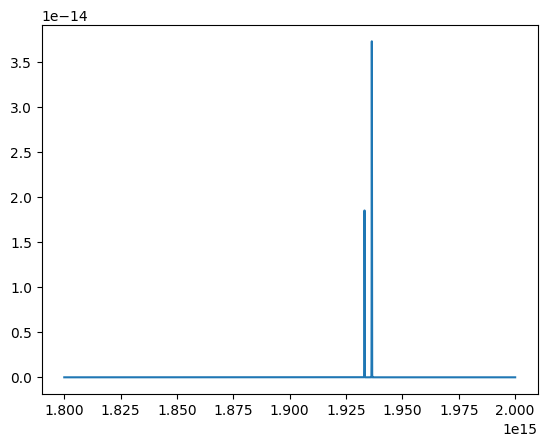

In [4]:
def H_voigt_fast(x, a):
    z = x + 1j*a
    return np.real(wofz(z))


v_th = 11.8 
sigma0 = (np.sqrt(np.pi)*emu_e**2) / (m_e*cc) 

del_nu_K = ((v_th) / cc_k) * CIV_nu_K
del_nu_H = ((v_th) / cc_k) * CIV_nu_H

x_K = ((nu - CIV_nu_K ) / del_nu_K)
x_H = ((nu - CIV_nu_H ) / del_nu_H)

a_K = C_IV_gamma_K / (4*np.pi*del_nu_K)  
a_H = C_IV_gamma_H / (4*np.pi*del_nu_H) 


K_term = (C_IV_f12_K /  del_nu_K) * H_voigt_fast(x_K, a_K)
H_term = (C_IV_f12_H /  del_nu_H) * H_voigt_fast(x_H, a_H)


cross_sec = sigma0 * (K_term + H_term) 

plt.plot(nu, cross_sec)
print(f"{1 / cross_sec.max():.2e}")


In [5]:
import numpy as np
from scipy.interpolate import PchipInterpolator

def del_v_peaks(Line, atom_num, atom_index, vout, vemit, vran):
    lam, spec_tot, spec_scat = K_H_from_Combine_data(
        Line, atom_num, atom_index, vout, vemit, vran
    )

    if lam[0] > lam[-1]:
        sort_idx = np.argsort(lam)
        lam = lam[sort_idx]
        spec_scat = spec_scat[sort_idx]

    if Line in ['k', 'K']:
        lambda_0 = C_IV_K_A
    elif Line in ['h', 'H']:
        lambda_0 = C_IV_H_A
    else:
        raise ValueError("Invalid Line input")

    win = 5.0
    mask0 = (lam >= lambda_0 - win) & (lam <= lambda_0 + win)
    lam_use = lam[mask0]
    spec_use = spec_scat[mask0]

    lam_fine = np.linspace(lam_use.min(), lam_use.max(), 50000)
    f = PchipInterpolator(lam_use, spec_use)
    spec_fine = f(lam_fine)

    grad = np.gradient(spec_fine, lam_fine)
    sign = np.sign(grad)

    for i in range(1, len(sign)):
        if sign[i] == 0:
            sign[i] = sign[i - 1]

    peak_idx = np.where((sign[:-1] > 0) & (sign[1:] < 0))[0] + 1
    peak_lambda_all = lam_fine[peak_idx]
    peak_values_all = spec_fine[peak_idx]

    mask = peak_values_all > 10000
    peak_lambda_all2 = peak_lambda_all[mask]
    peak_values_all2 = peak_values_all[mask]

    center_idx = np.argmin(np.abs(lam_fine - lambda_0))
    center_value = spec_fine[center_idx]

    order_all = np.argsort(peak_lambda_all2)
    peak_lambda_all2 = peak_lambda_all2[order_all]
    peak_values_all2 = peak_values_all2[order_all]

    if len(peak_lambda_all2) < 2:
        return 0.0, []

    if center_value >= 0.98 * np.max(peak_values_all2):
        return 0.0, []

    max_diff = -np.inf
    best_i, best_j = 0, 1

    for i in range(len(peak_lambda_all2)):
        for j in range(i + 1, len(peak_lambda_all2)):
            diff = peak_lambda_all2[j] - peak_lambda_all2[i]
            if diff > max_diff:
                max_diff = diff
                best_i, best_j = i, j

    peak_lambda = np.array([peak_lambda_all2[best_i], peak_lambda_all2[best_j]])
    del_v = ((peak_lambda[1] - lambda_0) / lambda_0) * cc_k * 2

    return del_v, peak_lambda

del_v = 0.0
peak_lambda = []


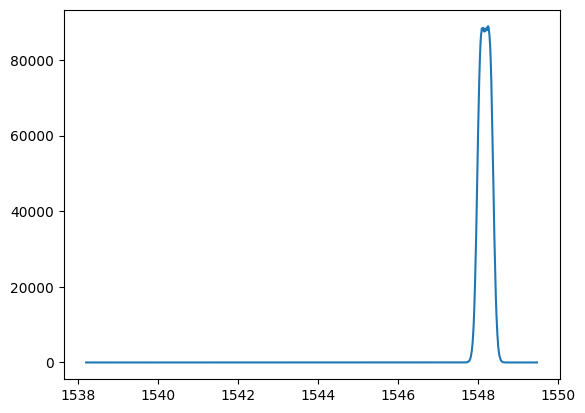

In [6]:
Line = "K"
atom_num = 13
atom_index = 14
vout = 0
vemit = 1
vran = 30

lam, spec_tot, spec_scat = K_H_from_Combine_data(Line, atom_num, atom_index, vout, vemit, vran)


plt.plot(lam, spec_scat, label='raw')
del_v, peak_lambda = del_v_peaks(Line, atom_num, atom_index, vout, vemit, vran)
print("del_v =", del_v)
print("peak_lambda =", peak_lambda)



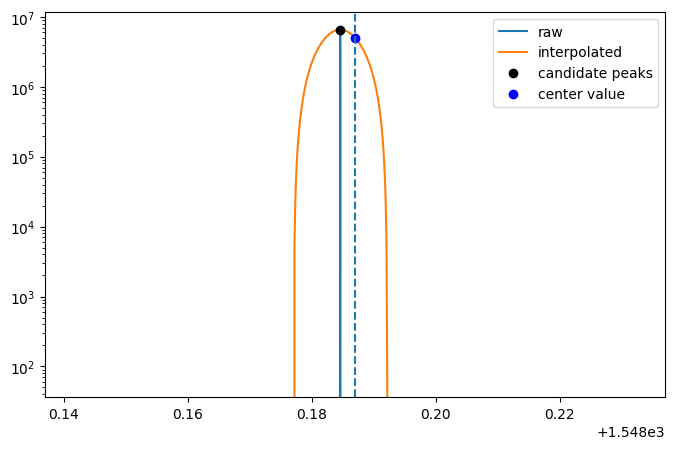

center_value = 4986665.110864333
max peak value = 6574332.8040336585
del_v = 0


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

Line = "K"
atom_num = 13
atom_index = 15
vout = 0
vemit = 0
vran = 11.8

lam, spec_tot, spec_scat = K_H_from_Combine_data(Line, atom_num, atom_index, vout, vemit, vran)

if lam[0] > lam[-1]:
    sort_idx = np.argsort(lam)
    lam = lam[sort_idx]
    spec_scat = spec_scat[sort_idx]

if Line in ['k', 'K']:
    lambda_0 = C_IV_K_A
elif Line in ['h', 'H']:
    lambda_0 = C_IV_H_A
else:
    raise ValueError("Invalid Line input")

# 중심 근처만 제한
win = 5.0
mask0 = (lam >= lambda_0 - win) & (lam <= lambda_0 + win)
lam_use = lam[mask0]
spec_use = spec_scat[mask0]

lam_fine = np.linspace(lam_use.min(), lam_use.max(), 50000)
f = PchipInterpolator(lam_use, spec_use)
spec_fine = f(lam_fine)

grad = np.gradient(spec_fine, lam_fine)
sign = np.sign(grad)

for i in range(1, len(sign)):
    if sign[i] == 0:
        sign[i] = sign[i - 1]

peak_idx = np.where((sign[:-1] > 0) & (sign[1:] < 0))[0] + 1
peak_lambda_all = lam_fine[peak_idx]
peak_values_all = spec_fine[peak_idx]

# 너무 작은 peak 제거
mask = peak_values_all > 10000
peak_lambda_all2 = peak_lambda_all[mask]
peak_values_all2 = peak_values_all[mask]

# 중심값
center_idx = np.argmin(np.abs(lam_fine - lambda_0))
center_value = spec_fine[center_idx]

# 파장 순 정렬
order_all = np.argsort(peak_lambda_all2)
peak_lambda_all2 = peak_lambda_all2[order_all]
peak_values_all2 = peak_values_all2[order_all]

del_v = 0
peak_lambda = []
peak_values = []

if len(peak_lambda_all2) >= 2:
    # 중심이 가장 높으면 double peak 아님
    if center_value >= np.max(peak_values_all2):
        del_v = 0
        peak_lambda = []
        peak_values = []
    else:
        max_diff = -np.inf
        best_i, best_j = 0, 1

        for i in range(len(peak_lambda_all2)):
            for j in range(i + 1, len(peak_lambda_all2)):
                diff = peak_lambda_all2[j] - peak_lambda_all2[i]
                if diff > max_diff:
                    max_diff = diff
                    best_i, best_j = i, j

        peak_lambda = np.array([peak_lambda_all2[best_i], peak_lambda_all2[best_j]])
        peak_values = np.array([peak_values_all2[best_i], peak_values_all2[best_j]])
        del_v = ((peak_lambda[1] - lambda_0) / lambda_0) * cc_k * 2

plt.figure(figsize=(8,5))
plt.plot(lam, spec_scat, label='raw')
plt.plot(lam_fine, spec_fine, label='interpolated')
plt.plot(peak_lambda_all2, peak_values_all2, 'ko', label='candidate peaks')
plt.plot(lam_fine[center_idx], center_value, 'bo', label='center value')

if len(peak_lambda) == 2:
    plt.plot(peak_lambda, peak_values, 'ro', label='max separation peaks')

plt.axvline(lambda_0, linestyle='--')
plt.xlim( C_IV_K_A - 0.05,  C_IV_K_A+0.05)
plt.yscale('log')
plt.legend()
plt.show()

print("center_value =", center_value)
print("max peak value =", np.max(peak_values_all2) if len(peak_values_all2) > 0 else None)
print("del_v =", del_v)

In [8]:
def H_voigt_fast(x, a):
    z = x + 1j*a
    return np.real(wofz(z))


# 우선 K line 만
def analytic_solution(Line,v_th):

    b = v_th  
    sigma0 = (np.sqrt(np.pi)*emu_e**2) / (m_e*cc) 

    del_nu_K = ((b) / cc_k) * CIV_nu_K
    del_nu_H = ((b) / cc_k) * CIV_nu_H

    x_K = ((nu - CIV_nu_K ) / del_nu_K)
    x_H = ((nu - CIV_nu_H ) / del_nu_H)
    
    a_K = C_IV_gamma_K / (4*np.pi*del_nu_K)
    a_H = C_IV_gamma_H / (4*np.pi*del_nu_H)


    K_term = (C_IV_f12_K /  del_nu_K) * H_voigt_fast(x_K, a_K) / np.sqrt(2)
    H_term = (C_IV_f12_H /  del_nu_H) * H_voigt_fast(x_H, a_H)  / np.sqrt(2)


    cross_sec = sigma0 * (K_term + H_term) 



    K_region = np.where((Del_V >= -V_c) & (Del_V <= V_c))
    H_region = np.where((Del_V >= Vsep-V_c) & (Del_V <= Vsep + V_c))

    delV_K,cs_K = Del_V[K_region], cross_sec[K_region]
    delV_H, cs_H  = Del_V[H_region], cross_sec[H_region]

    x_kk = delV_K / (-b) 
    x_hh = (delV_H-Vsep) / (-b) 


    tau_profile_K = C_iv_N[:, None] * cs_K
    tau_profile_H = C_iv_N[:, None] * cs_H

    x_esc = np.zeros(len(C_iv_N))
    
    if Line.upper() == 'K':
        for ii in range(len(C_iv_N)):
            
            tau_i = tau_profile_K[ii, :]
            s = tau_i - 1.0

            # Find sign changes of (tau - 1) and linearly interpolate x where tau=1
            cross_idx = np.where(np.sign(s[:-1]) * np.sign(s[1:]) < 0)[0]

            if cross_idx.size == 0:
                x_esc[ii] = 0.0
                continue

            x_candidates = []
            for jj in cross_idx:
                tau_a, tau_b = tau_i[jj], tau_i[jj + 1]
                x_a, x_b = x_kk[jj], x_kk[jj + 1]

                if tau_b == tau_a:
                    continue

                x_cross = x_a + (1.0 - tau_a) * (x_b - x_a) / (tau_b - tau_a)
                x_candidates.append(x_cross)

            # Keep the maximum x (matches original idea of choosing the positive boundary)
            x_esc[ii] = max(x_candidates) if len(x_candidates) > 0 else 0.0

            del_lam_D = (b*1e5) / C_IV_K
            nu_0_K= cc/C_IV_K
            real_x_esc = x_esc 
            nu_esc = real_x_esc*del_lam_D + nu_0_K
            V_peak_sep = 2 * abs((nu_esc - nu_0_K)/nu_0_K) * cc/1e5  #km/s
            v_esc = x_esc*b
            N_esc= 1/special.erfc(real_x_esc)
        return delV_K,cs_K , real_x_esc , V_peak_sep, N_esc

    elif Line.upper() == 'H':
        for ii in range(len(C_iv_N)):
            
            tau_i = tau_profile_H[ii, :]
            s = tau_i - 1.0

            # Find sign changes of (tau - 1) and linearly interpolate x where tau=1
            cross_idx = np.where(np.sign(s[:-1]) * np.sign(s[1:]) < 0)[0]

            if cross_idx.size == 0:
                x_esc[ii] = 0.0
                continue

            x_candidates = []
            for jj in cross_idx:
                tau_a, tau_b = tau_i[jj], tau_i[jj + 1]
                x_a, x_b = x_hh[jj], x_hh[jj + 1]

                if tau_b == tau_a:
                    continue

                x_cross = x_a + (1.0 - tau_a) * (x_b - x_a) / (tau_b - tau_a)
                x_candidates.append(x_cross)

            # Keep the maximum x (matches original idea of choosing the positive boundary)
            x_esc[ii] = max(x_candidates) if len(x_candidates) > 0 else 0.0

            del_lam_D = (b*1e5) / C_IV_H
            nu_0_H= cc/C_IV_H
            real_x_esc = x_esc 
            nu_esc = real_x_esc*del_lam_D + nu_0_H
            V_peak_sep = 2 * abs((nu_esc - nu_0_H)/nu_0_H) * cc/1e5 #km/s
            v_esc = real_x_esc*b
            N_esc= 1/special.erfc(real_x_esc)
        return  delV_H,cs_H , real_x_esc , V_peak_sep, N_esc


In [9]:
def tau0_K_from_pdf(v_th, N_CIV):
    sigma_pref = np.sqrt(np.pi) * emu_e**2 / (m_e * cc)
    del_nu_K = (v_th / cc_k) * CIV_nu_K
    sigma0_K = sigma_pref * (C_IV_f12_K / del_nu_K)   # H(0,a) ~ 1
    return N_CIV * sigma0_K, sigma0_K

tau0, sigma0K = tau0_K_from_pdf(11.8, 2.67e13)
print("sigma0_K =", sigma0K)
print("tau0 =", tau0)

sigma0_K = 3.737040093631413e-14
tau0 = 0.9977897049995873


In [10]:
vrand = np.array([11.8, 30, 50])

for rand in vrand:
    name = str(rand).replace('.', '_')

    (globals()[f"Del_V_{name}"],
     globals()[f"cross_sec_{name}"],
     globals()[f"x_esc_{name}"],
     globals()[f"V_peak_sep_{name}"],
     globals()[f"N_esc_{name}"]) = analytic_solution('K', rand)

    globals()[f"tau0_{name}"] = globals()[f"cross_sec_{name}"].max() * C_iv_N

In [11]:
print(1 / globals()[f"cross_sec_30_0"].max())

96257174965092.4


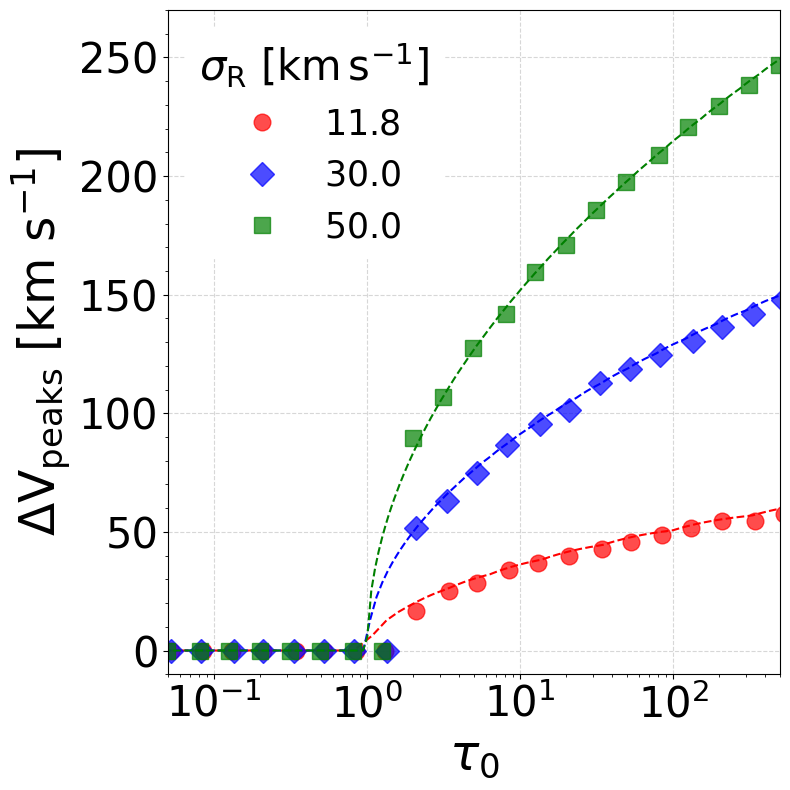

In [12]:
fig = plt.figure(1,figsize=(8,8))

vrand = np.array([11.8,30.0,50.0])
shape= np.array(['o','D','s'])
color = ['r','b','g']

rr = np.arange(12, 17, 1)
atom_N = [13,20,32,50,79]
total_N_c = np.outer(10**rr, atom_N) / 10
total_N_c = total_N_c.flatten()

for kk,rand in enumerate (vrand):
    name = str(rand).replace('.', '_')

    vv = []
    tau = np.array([])
    for ii, index in enumerate(rr):
        for jj , atom in enumerate(atom_N):
            # print(del_v_peaks('k',atom,index,0,1,rand))
            a , lam = del_v_peaks('k',atom,index,0,1,rand)
            vv.append(a)
            nciv = (atom/10)*10**index
            b = ((atom/10)*10**index)*globals()[f"cross_sec_{name}"].max()
            tau = np.append(tau,b)


            
    plt.plot(globals()[f"tau0_{name}"], globals()[f"V_peak_sep_{name}"], linestyle='--',color=color[kk])
    plt.plot(tau  , vv,marker=shape[kk],linestyle='',markersize=12,alpha=0.7,color = color[kk],label = r'${}$'.format(rand))

    
# for ii,rand in enumerate (vrand):
#     name = str(rand).replace('.', '_')

#     plt.plot(globals()[f"tau0_{name}"], globals()[f"V_peak_sep_{name}"], linestyle='--',color=color[ii],label=f'{rand} km/s')


plt.xlabel(r'${\tau_0}$',fontsize =35)
plt.xscale('log')
plt.xlim(5e-2,5e2)
plt.xticks(fontsize=30)


plt.ylabel(r'$\Delta \mathrm{V}_{\mathrm{peaks}}$ [km s$^{-1}$]',fontsize =35)
plt.ylim(-10,270)
plt.yticks(fontsize=30)

plt.minorticks_on()


plt.grid(True,linestyle='--',alpha=0.5)
leg = plt.legend(
    fontsize=25,
    title=r'$\sigma_{\rm R} ~ [\rm km\,s^{-1}]$',
    loc='upper left',
    title_fontsize=30,
    frameon=True
)
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(1)
leg.get_frame().set_edgecolor('white') 
plt.tight_layout()

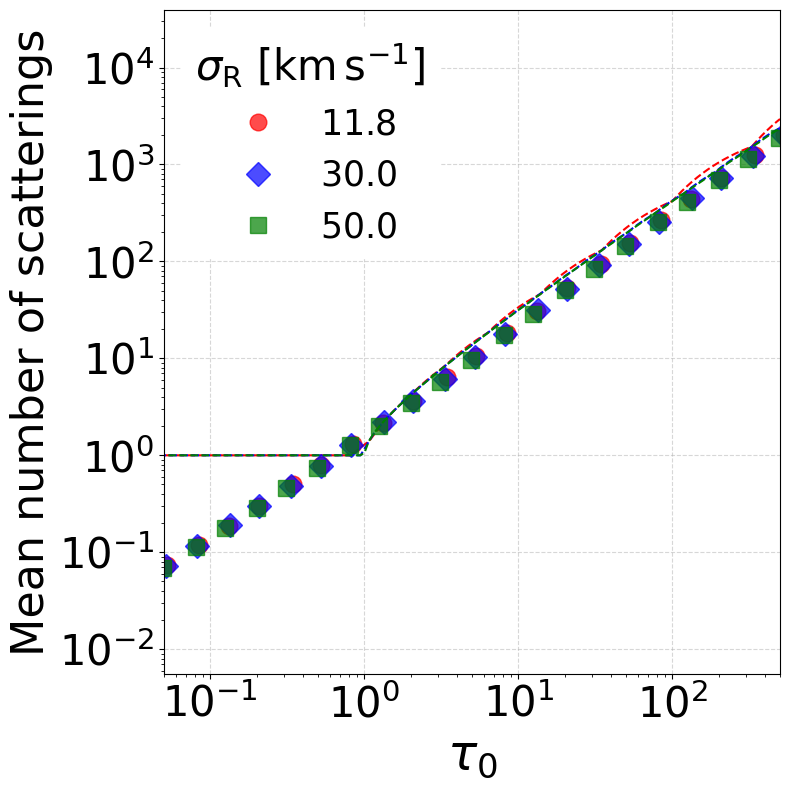

In [13]:
fig = plt.figure(1,figsize=(8,8))

vrand = np.array([11.8, 30, 50])
shape= np.array(['o','D','s'])
color = ['r','b','g']

rr = np.arange(12, 17, 1)
atom_N = [13,20,32,50,79]
total_N_c = np.outer(10**rr, atom_N) / 10
total_N_c = total_N_c.flatten()

for kk,rand in enumerate (vrand):
    name = str(rand).replace('.', '_')

    vv = []
    for ii, index in enumerate(rr):
        for jj , atom in enumerate(atom_N):
            a = data_scat('k',atom,index,0,1,rand)
            vv.append(a)
            
    plt.plot(globals()[f"tau0_{name}"], globals()[f"N_esc_{name}"], linestyle='--',color=color[kk])
    plt.plot(total_N_c*globals()[f"cross_sec_{name}"].max() , vv,marker=shape[kk],linestyle='',markersize=12,alpha=0.7,color = color[kk],label = r'${}$'.format(rand))

    
# for ii,rand in enumerate (vrand):
#     name = str(rand).replace('.', '_')

#     plt.plot(globals()[f"tau0_{name}"], globals()[f"V_peak_sep_{name}"], linestyle='--',color=color[ii],label=f'{rand} km/s')


plt.xlabel(r'${\tau_0}$',fontsize =35)
plt.xscale('log')
plt.xlim(5e-2,5e2)
plt.xticks(fontsize=30)


plt.ylabel(r'Mean number of scatterings',fontsize =32)
plt.yscale('log')
plt.yticks(fontsize=30)

plt.minorticks_on()


plt.grid(True,linestyle='--',alpha=0.5)
leg = plt.legend(
    fontsize=25,
    title=r'$\sigma_{\rm R} ~ [\rm km\,s^{-1}]$',
    loc='upper left',
    title_fontsize=30,
    frameon=True
)
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(1)
leg.get_frame().set_edgecolor('white') 
plt.tight_layout()

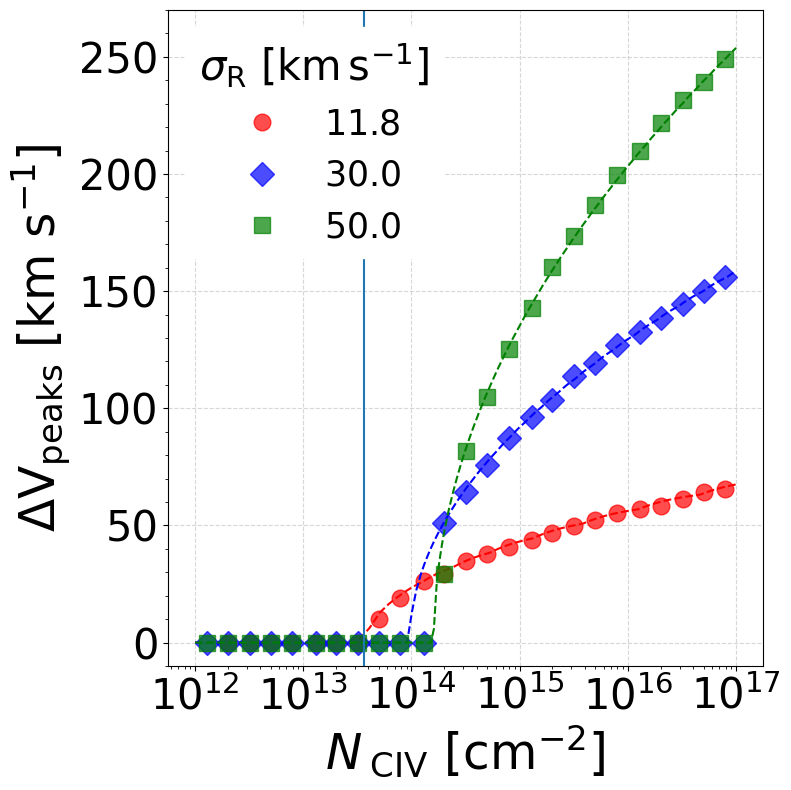

In [20]:
fig = plt.figure(1,figsize=(8,8))

vrand = np.array([11.8, 30, 50])
shape= np.array(['o','D','s'])
color = ['r','b','g']

rr = np.arange(12, 17, 1)
atom_N = [13,20,32,50,79]
total_N_c = np.outer(10**rr, atom_N) / 10
total_N_c = total_N_c.flatten()


# for kk , rand in enumerate(vrand):

#     vv = []
#     for ii, index in enumerate(rr):
#         for jj , atom in enumerate(atom_N):
#             a , lam = del_v_peaks('k',atom,index,0,1,rand)
#             vv.append(a)

for kk,rand in enumerate (vrand):
    name = str(rand).replace('.', '_')

    vv = []
    for ii, index in enumerate(rr):
        for jj , atom in enumerate(atom_N):
            a , lam = del_v_peaks('k',atom,index,0,1,rand)
            vv.append(a)
            
    plt.plot(C_iv_N, globals()[f"V_peak_sep_{name}"], linestyle='--',color=color[kk])
    plt.plot(total_N_c, vv,marker=shape[kk],linestyle='',markersize=12,alpha=0.7,color = color[kk],label = r'${}$'.format(rand))
plt.xlabel(r'${N} \, _{\mathrm{C IV}}$ [cm$^{-2}$]',fontsize =35)
plt.xscale('log')
plt.xticks(fontsize=30)

plt.axvline(x=3.67e13,ymin=0,ymax=1)


plt.ylabel(r'$\Delta \mathrm{V}_{\mathrm{peaks}}$ [km s$^{-1}$]',fontsize =35)
plt.ylim(-10,270)
plt.yticks(fontsize=30)

plt.minorticks_on()


plt.grid(True,linestyle='--',alpha=0.5)
leg = plt.legend(
    fontsize=25,
    title=r'$\sigma_{\rm R} ~ [\rm km\,s^{-1}]$',
    loc='upper left',
    title_fontsize=30,
    frameon=True
)
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(1)
leg.get_frame().set_edgecolor('white') 
plt.tight_layout()

RT_scat

In [15]:
#

def calculate_order_and_value(value):
    """ 주어진 값에 대해 변환된 값과 해당 order 반환 """

    if value == 0 :
        return "000" , 0
    elif value == 1:
        return int(value * 100), 0
    elif value < 100:
        return int(value * 10), 1
    elif value < 1000:
        return int(value), 2
    else :
        return int(value / 10), 3


#combine K and H lines
def K_H_from_Combine_data_com(Line , atom_num , atom_index, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)

    path = r'/home/jin/data_CIV/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}spec_com.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)


    lam = data[0].to_numpy()
    spec_tot = data[1].to_numpy()
    spec_sc = data[2].to_numpy()
   # spec_pol_tot = data[3]
   # spec_pol_scat = data[4]
    return lam , spec_tot , spec_sc



#separate K and H line
def K_H_from_Combine_data_x(Line , atom_num , atom_index, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)

    path = r'/home/jin/data_CIV/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}spec.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)


    x = data[0].to_numpy()
    if Line == 'h' or Line =='H':
        lam = -  C_IV_H_A / ( (vran/cc_k)*x -1)
        spec_tot = data[2].to_numpy()
        spec_scat = data[4].to_numpy()

    elif Line == 'k' or Line =='K':
        lam = - C_IV_K_A / ( (vran/cc_k)*x -1)
        spec_tot = data[1].to_numpy()
        spec_scat = data[3].to_numpy()       

    
    return lam , spec_tot , spec_scat , x


def data_scat(Line , atom_num , atom_index, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)

    path = r'/home/jin/data_CIV/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}_f_esc.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)

    if Line == 'k' or Line =='K':
        N_sct = data.iloc[0,4]

    elif Line == 'h' or Line =='H':
        N_sct = data.iloc[0,5]

    return N_sct
    


def K_H_from_Combine_data(Line , atom_num , atom_index, vout, vemit, vran):
    lam , spec_tot , spec_halo =  K_H_from_Combine_data_com(Line , atom_num , atom_index, vout, vemit, vran)
    lam_c =  (C_IV_K_A + C_IV_H_A) / 2
    if Line == 'k' or Line =='K':
        ioc = np.where(lam<=lam_c)[0]
        lam_x = lam[ioc]
        spec_tot_x = spec_tot[ioc]
        spec_halo_x  = spec_halo[ioc]

    elif Line == 'h' or Line =='H':
        ioc = np.where(lam>=lam_c)[0]
        lam_x = lam[ioc]
        spec_tot_x = spec_tot[ioc]
        spec_halo_x  = spec_halo[ioc]
    else :
        lam_x  = lam 
        spec_tot_x = spec_tot
        spec_halo_x = spec_halo

    return lam_x , spec_tot_x , spec_halo_x

def del_v_peaks(Line, atom_num, atom_index, vout, vemit, vran):
    lam, spec_tot, spec_halo = K_H_from_Combine_data_com(Line, atom_num, atom_index, vout, vemit, vran)
    from scipy.signal import find_peaks
    # 모든 피크 찾기
    f = interp1d(lam, spec_halo, kind='cubic')
    lam_fine = np.linspace(lam.min(), lam.max(), len(lam) * 20)
    spec_fine = f(lam_fine)

    peaks, properties = find_peaks(spec_fine)

    if len(peaks) < 2:
        del_v = 0
        peak_lambda = []
        peak_values = []
    else:
        peak_intensities = spec_fine[peaks]
        top_2 = np.argsort(peak_intensities)[-2:]
        top_2_indices = peaks[top_2]
        top_2_indices = np.sort(top_2_indices)

        peak_lambda = lam_fine[top_2_indices]
        peak_values = spec_fine[top_2_indices]

    if Line in ['k', 'K']:
        lambda_0 = C_IV_K_A
    elif Line in ['h', 'H']:
        lambda_0 = C_IV_H_A
    else:
        raise ValueError("Invalid Line input. Must be 'k' or 'h'.")

    if abs(peak_values[0] - peak_values[1]) > 20000 or abs(peak_lambda[0] - peak_lambda[1]) < 0.05:
        del_v = 0
    else:
        peak_velocities = cc_k * (peak_lambda - lambda_0) / lambda_0
        del_v = abs(peak_velocities[1] - peak_velocities[0])

    return del_v, peak_lambda
    

(1547.5, 1549.5)

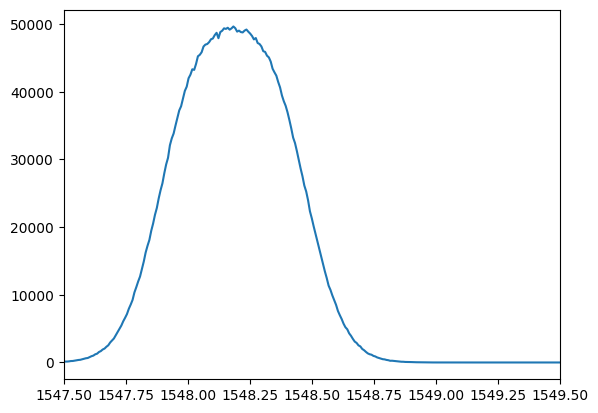

In [16]:
from scipy.signal import find_peaks
lam, spec_tot, spec_halo = K_H_from_Combine_data_com("K", 13, 14, 0, 1, 50)
Line ='K'
    # 모든 피크 찾기
peaks, properties = find_peaks(spec_halo)
if len(peaks) < 2:
    # 피크가 2개 미만이면 del_v = 0
    del_v = 0
    peak_lambda = []
    peak_values = []
else:
    # 모든 피크 중 강도 높은 상위 2개 선택
    peak_intensities = spec_halo[peaks]
    top_2_indices = np.argsort(peak_intensities)[-2:]  # 가장 강한 2개의 피크 선택
    top_2_indices = peaks[top_2_indices]  # 원래 인덱스로 변환

    # 피크 파장 및 강도
    peak_lambda = lam[top_2_indices]
    peak_values = spec_halo[top_2_indices]

    # 기준 파장 설정 (C_IV_K_A, C_IV_H_A는 미리 정의되어 있어야 함)
    if Line in ['k', 'K']:
        lambda_0 = C_IV_K_A
    elif Line in ['h', 'H']:
        lambda_0 = C_IV_H_A
    else:
        raise ValueError("Invalid Line input. Must be 'k' or 'h'.")

    # **추가: 피크 강도 차이가 10,000 이상이면 double peak이 아님**
    if abs(peak_values[0] - peak_values[1]) > 20000  or abs(peak_lambda[0] - peak_lambda[1]) < 0.05 :
        del_v = 0
    else:
        # 속도 변환 (v = c * (lambda - lambda_0) / lambda_0)
        peak_velocities = cc_k * (peak_lambda - lambda_0) / lambda_0
        del_v = abs(peak_velocities[1] - peak_velocities[0])  # 속도 차이 계산

# return del_v, peak_lambda

plt.plot(lam,spec_halo)
plt.xlim(1547.5,1549.5)

peak_lambda = [1548.01888657 1548.35078135]
peak_values = [97614.35371558 97492.70558426]
del_v = 64.26843292647214


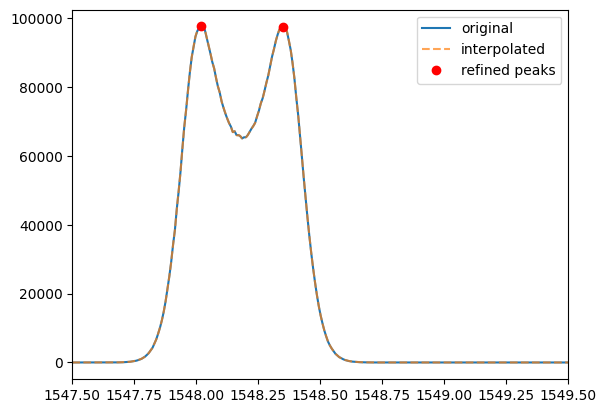

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.interpolate import interp1d

lam, spec_tot, spec_halo = K_H_from_Combine_data_com("K", 32, 14, 0, 1, 30)
Line = 'K'

f = interp1d(lam, spec_halo, kind='cubic')
lam_fine = np.linspace(lam.min(), lam.max(), len(lam) * 20)
spec_fine = f(lam_fine)

peaks, properties = find_peaks(spec_fine)

if len(peaks) < 2:
    del_v = 0
    peak_lambda = []
    peak_values = []
else:
    peak_intensities = spec_fine[peaks]
    top_2 = np.argsort(peak_intensities)[-2:]
    top_2_indices = peaks[top_2]
    top_2_indices = np.sort(top_2_indices)

    peak_lambda = lam_fine[top_2_indices]
    peak_values = spec_fine[top_2_indices]

    if Line in ['k', 'K']:
        lambda_0 = C_IV_K_A
    elif Line in ['h', 'H']:
        lambda_0 = C_IV_H_A
    else:
        raise ValueError("Invalid Line input. Must be 'k' or 'h'.")

    if abs(peak_values[0] - peak_values[1]) > 20000 or abs(peak_lambda[0] - peak_lambda[1]) < 0.05:
        del_v = 0
    else:
        peak_velocities = cc_k * (peak_lambda - lambda_0) / lambda_0
        del_v = abs(peak_velocities[1] - peak_velocities[0])

print("peak_lambda =", peak_lambda)
print("peak_values =", peak_values)
print("del_v =", del_v)

plt.plot(lam, spec_halo, label='original')
plt.plot(lam_fine, spec_fine, '--', alpha=0.7, label='interpolated')
if len(peaks) >= 2:
    plt.plot(peak_lambda, peak_values, 'ro', label='refined peaks')
plt.xlim(1547.5, 1549.5)
plt.legend()
plt.show()

In [18]:
def del_v_peaks(Line, atom_num, atom_index, vout, vemit, vran):
    lam, spec_tot, spec_halo = K_H_from_Combine_data_com(Line, atom_num, atom_index, vout, vemit, vran)
    from scipy.signal import find_peaks
    # 모든 피크 찾기
    peaks, properties = find_peaks(spec_halo)

    if len(peaks) < 2:
        # 피크가 2개 미만이면 del_v = 0
        del_v = 0
        peak_lambda = []
        peak_values = []
    else:
        # 모든 피크 중 강도 높은 상위 2개 선택
        peak_intensities = spec_halo[peaks]
        top_2_indices = np.argsort(peak_intensities)[-2:]  # 가장 강한 2개의 피크 선택
        top_2_indices = peaks[top_2_indices]  # 원래 인덱스로 변환

        # 피크 파장 및 강도
        peak_lambda = lam[top_2_indices]
        peak_values = spec_halo[top_2_indices]

        # 기준 파장 설정 (C_IV_K_A, C_IV_H_A는 미리 정의되어 있어야 함)
        if Line in ['k', 'K']:
            lambda_0 = C_IV_K_A
        elif Line in ['h', 'H']:
            lambda_0 = C_IV_H_A
        else:
            raise ValueError("Invalid Line input. Must be 'k' or 'h'.")

        # **추가: 피크 강도 차이가 10,000 이상이면 double peak이 아님**
        if abs(peak_values[0] - peak_values[1]) > 20000  or abs(peak_lambda[0] - peak_lambda[1]) < 0.05 :
            del_v = 0
        else:
            # 속도 변환 (v = c * (lambda - lambda_0) / lambda_0)
            peak_velocities = cc_k * (peak_lambda - lambda_0) / lambda_0
            del_v = abs(peak_velocities[1] - peak_velocities[0])  # 속도 차이 계산

    return del_v, peak_lambda